In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/australia_cost_of_living_clean.csv")

df.shape

(8, 56)

In [3]:
df.head()

,city,numbeo_update_date,restaurant_inexpensive,restaurant_midrange_two,mcdonalds_combo,domestic_draft_beer,imported_beer,cappuccino,soft_drink,water_033l,...,mens_business_shoes,rent_1br_city_centre,rent_1br_outside_centre,rent_3br_city_centre,rent_3br_outside_centre,buy_price_sqm_city_centre,buy_price_sqm_outside_centre,average_monthly_net_salary,mortgage_interest_rate,data_status
0,Sydney,2026-08-15,25.0,124.0,16.00,10.5,10.0,5.48,3.88,3.12,...,180.36,3517.50,2403.33,6990.00,3987.08,18395.00,11274.69,6010.70,5.81,complete
1,Melbourne,2026-08-17,25.0,115.0,17.00,14.0,12.0,5.71,4.43,3.59,...,185.33,2411.13,1979.54,4815.08,3500.73,10026.39,9020.78,6286.11,5.65,complete
2,Brisbane,2026-08-17,25.0,120.0,16.00,12.0,12.0,6.20,4.08,3.44,...,154.62,2890.19,2018.44,4969.15,3410.42,11891.06,8759.42,5950.63,6.01,complete
3,Perth,2026-08-14,29.0,122.5,15.38,12.0,12.0,6.08,4.05,3.15,...,224.00,2711.62,2272.00,3951.36,3070.00,11887.22,8149.92,6085.66,5.96,complete
4,Adelaide,2026-08-15,25.0,120.0,16.00,11.0,12.5,5.74,4.08,3.63,...,191.25,2518.00,1930.00,3504.00,2690.00,14595.38,9915.46,5494.61,6.07,complete


In [4]:
rent_cols = [
    "rent_1br_city_centre",
    "rent_1br_outside_centre",
    "rent_3br_city_centre",
    "rent_3br_outside_centre"
]

df[["city"] + rent_cols]

,city,rent_1br_city_centre,rent_1br_outside_centre,rent_3br_city_centre,rent_3br_outside_centre
0,Sydney,3517.50,2403.33,6990.00,3987.08
1,Melbourne,2411.13,1979.54,4815.08,3500.73
2,Brisbane,2890.19,2018.44,4969.15,3410.42
3,Perth,2711.62,2272.00,3951.36,3070.00
4,Adelaide,2518.00,1930.00,3504.00,2690.00
5,Canberra,2485.45,2111.82,4424.44,2838.89
6,Hobart,2600.00,1970.00,3080.00,2330.00
7,Darwin,2500.00,2426.67,3873.33,3270.00


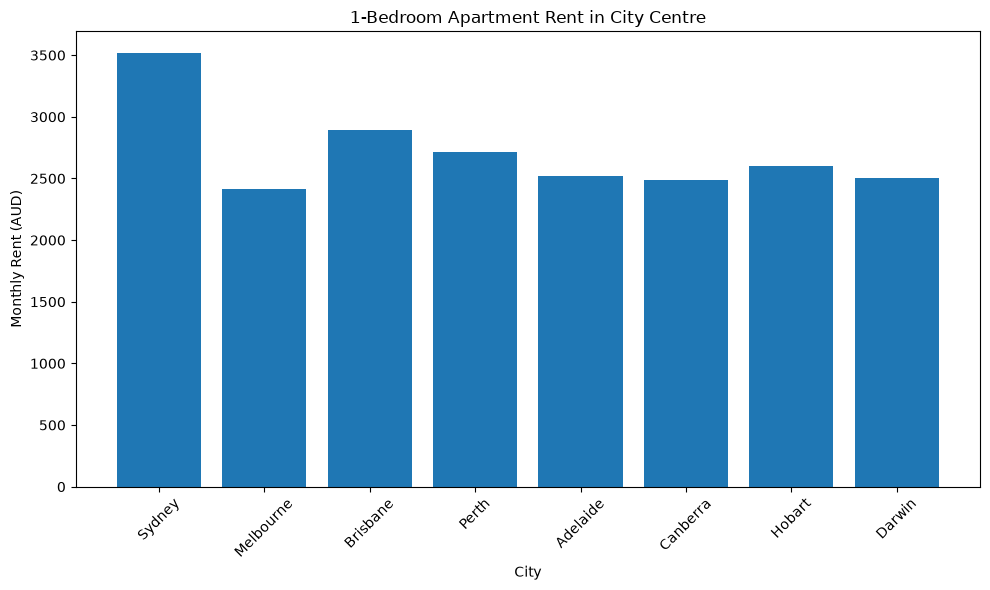

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(df["city"], df["rent_1br_city_centre"])

plt.title("1-Bedroom Apartment Rent in City Centre")
plt.xlabel("City")
plt.ylabel("Monthly Rent (AUD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

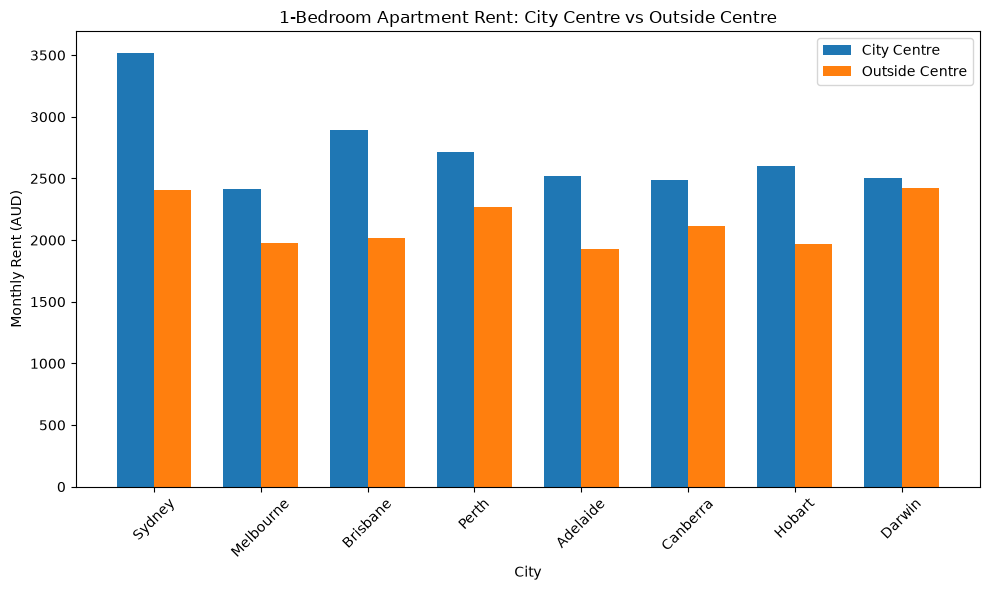

In [6]:
plt.figure(figsize=(10, 6))

x = np.arange(len(df))
width = 0.35

plt.bar(
    x - width/2,
    df["rent_1br_city_centre"],
    width,
    label="City Centre"
)

plt.bar(
    x + width/2,
    df["rent_1br_outside_centre"],
    width,
    label="Outside Centre"
)

plt.title("1-Bedroom Apartment Rent: City Centre vs Outside Centre")
plt.xlabel("City")
plt.ylabel("Monthly Rent (AUD)")
plt.xticks(x, df["city"], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

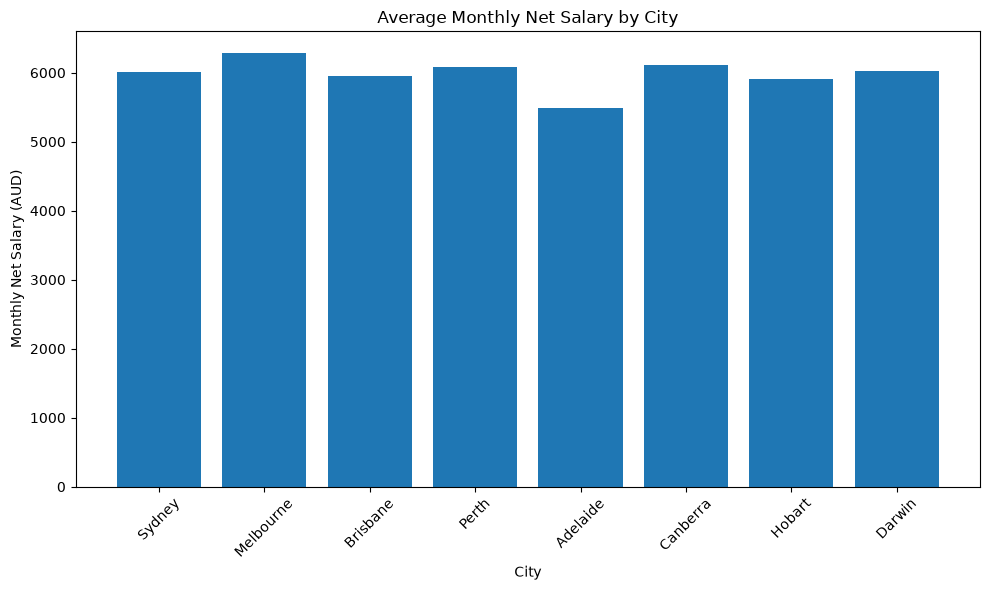

In [7]:
plt.figure(figsize=(10, 6))

plt.bar(df["city"], df["average_monthly_net_salary"])

plt.title("Average Monthly Net Salary by City")
plt.xlabel("City")
plt.ylabel("Monthly Net Salary (AUD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [8]:
df["rent_burden_pct"] = (
    df["rent_1br_outside_centre"] /
    df["average_monthly_net_salary"]
) * 100

df[[
    "city",
    "rent_1br_outside_centre",
    "average_monthly_net_salary",
    "rent_burden_pct"
]]

,city,rent_1br_outside_centre,average_monthly_net_salary,rent_burden_pct
0,Sydney,2403.33,6010.70,39.984195
1,Melbourne,1979.54,6286.11,31.490699
2,Brisbane,2018.44,5950.63,33.919770
3,Perth,2272.00,6085.66,37.333666
4,Adelaide,1930.00,5494.61,35.125332
5,Canberra,2111.82,6107.53,34.577317
6,Hobart,1970.00,5914.87,33.305888
7,Darwin,2426.67,6024.48,40.280157


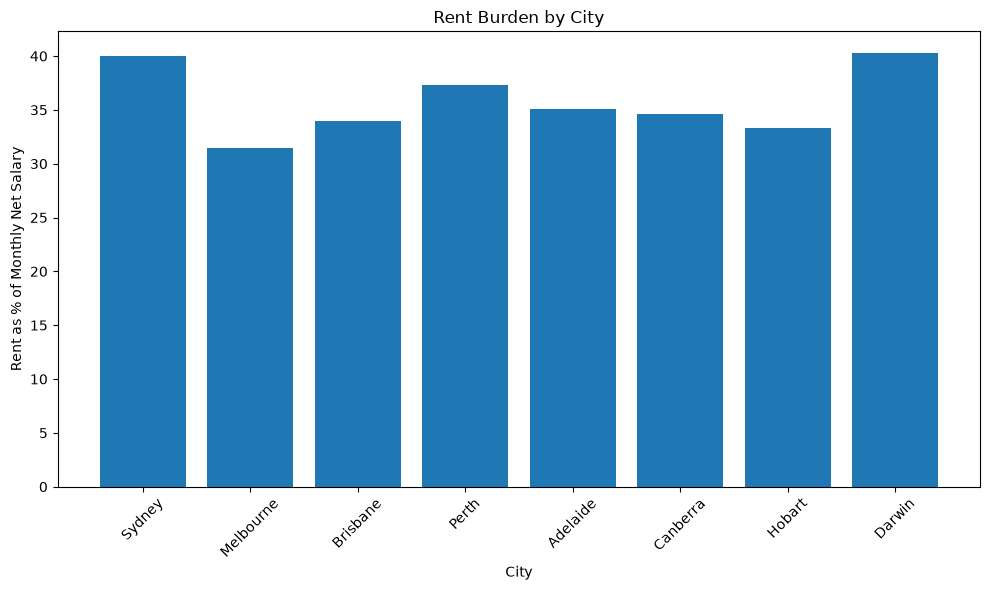

In [9]:
plt.figure(figsize=(10, 6))

plt.bar(df["city"], df["rent_burden_pct"])

plt.title("Rent Burden by City")
plt.xlabel("City")
plt.ylabel("Rent as % of Monthly Net Salary")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
df["income_after_rent"] = (
    df["average_monthly_net_salary"] -
    df["rent_1br_outside_centre"]
)

df[[
    "city",
    "average_monthly_net_salary",
    "rent_1br_outside_centre",
    "income_after_rent"
]]

,city,average_monthly_net_salary,rent_1br_outside_centre,income_after_rent
0,Sydney,6010.70,2403.33,3607.37
1,Melbourne,6286.11,1979.54,4306.57
2,Brisbane,5950.63,2018.44,3932.19
3,Perth,6085.66,2272.00,3813.66
4,Adelaide,5494.61,1930.00,3564.61
5,Canberra,6107.53,2111.82,3995.71
6,Hobart,5914.87,1970.00,3944.87
7,Darwin,6024.48,2426.67,3597.81


In [11]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. city
2. numbeo_update_date
3. restaurant_inexpensive
4. restaurant_midrange_two
5. mcdonalds_combo
6. domestic_draft_beer
7. imported_beer
8. cappuccino
9. soft_drink
10. water_033l
11. milk_1l
12. bread_500g
13. rice_1kg
14. eggs_12
15. local_cheese_1kg
16. chicken_1kg
17. beef_1kg
18. apples_1kg
19. bananas_1kg
20. oranges_1kg
21. tomatoes_1kg
22. potatoes_1kg
23. onions_1kg
24. lettuce_1head
25. water_15l
26. wine_midrange
27. domestic_beer_05l
28. imported_beer_033l
29. cigarettes_20
30. transport_one_way
31. transport_monthly_pass
32. taxi_start
33. taxi_per_km
34. taxi_wait_hour
35. gasoline_1l
36. utilities_85sqm
37. mobile_plan
38. internet
39. gym_membership
40. tennis_hour
41. cinema_ticket
42. preschool_monthly
43. international_primary_annual
44. jeans
45. summer_dress
46. nike_running_shoes
47. mens_business_shoes
48. rent_1br_city_centre
49. rent_1br_outside_centre
50. rent_3br_city_centre
51. rent_3br_outside_centre
52. buy_price_sqm_city_centre
53. buy_price_sqm_outs

In [12]:
for i, col in enumerate(df.columns, start=1):
    if 25 <= i <= 54:
        print(f"{i}. {col}")

25. water_15l
26. wine_midrange
27. domestic_beer_05l
28. imported_beer_033l
29. cigarettes_20
30. transport_one_way
31. transport_monthly_pass
32. taxi_start
33. taxi_per_km
34. taxi_wait_hour
35. gasoline_1l
36. utilities_85sqm
37. mobile_plan
38. internet
39. gym_membership
40. tennis_hour
41. cinema_ticket
42. preschool_monthly
43. international_primary_annual
44. jeans
45. summer_dress
46. nike_running_shoes
47. mens_business_shoes
48. rent_1br_city_centre
49. rent_1br_outside_centre
50. rent_3br_city_centre
51. rent_3br_outside_centre
52. buy_price_sqm_city_centre
53. buy_price_sqm_outside_centre
54. average_monthly_net_salary


In [13]:
food_cols = [
    "milk_1l",
    "bread_500g",
    "rice_1kg",
    "eggs_12",
    "local_cheese_1kg",
    "chicken_1kg",
    "beef_1kg",
    "apples_1kg",
    "bananas_1kg",
    "oranges_1kg",
    "tomatoes_1kg",
    "potatoes_1kg",
    "onions_1kg",
    "lettuce_1head",
    "water_15l"
]

df[["city"] + food_cols]

,city,milk_1l,bread_500g,rice_1kg,eggs_12,local_cheese_1kg,chicken_1kg,beef_1kg,apples_1kg,bananas_1kg,oranges_1kg,tomatoes_1kg,potatoes_1kg,onions_1kg,lettuce_1head,water_15l
0,Sydney,2.65,3.70,3.36,7.70,17.39,13.73,23.43,5.23,4.36,4.71,6.49,4.32,3.50,3.30,1.72
1,Melbourne,2.46,4.61,4.00,8.49,15.14,13.62,21.64,5.95,4.43,4.76,6.92,4.66,3.87,3.56,2.32
2,Brisbane,2.50,3.75,3.01,7.22,13.23,12.41,19.85,5.75,4.31,4.25,7.01,4.04,3.35,3.56,1.78
3,Perth,2.34,4.33,2.86,7.49,12.42,13.14,19.86,6.34,4.60,4.73,7.47,4.03,2.79,3.26,1.91
4,Adelaide,2.93,4.15,3.16,8.07,15.46,13.13,24.92,5.59,4.23,5.20,7.14,4.71,3.46,3.62,3.23
5,Canberra,2.29,4.70,3.74,7.61,19.68,15.23,22.80,5.71,4.53,5.02,7.22,4.46,3.77,3.84,2.06
6,Hobart,2.55,3.52,2.66,8.08,13.95,12.43,25.00,4.46,4.67,4.23,6.65,3.70,3.15,3.70,2.37
7,Darwin,2.17,4.35,3.21,6.34,13.00,12.00,13.00,5.62,4.00,3.98,7.22,3.67,3.37,3.00,3.07


In [14]:
monthly_quantities = {
    "milk_1l": 8,
    "bread_500g": 8,
    "rice_1kg": 4,
    "eggs_12": 2,
    "local_cheese_1kg": 0.5,
    "chicken_1kg": 2,
    "beef_1kg": 1,
    "apples_1kg": 2,
    "bananas_1kg": 2,
    "oranges_1kg": 1,
    "tomatoes_1kg": 2,
    "potatoes_1kg": 2,
    "onions_1kg": 1,
    "lettuce_1head": 4,
    "water_15l": 4
}

monthly_quantities

{'milk_1l': 8,
 'bread_500g': 8,
 'rice_1kg': 4,
 'eggs_12': 2,
 'local_cheese_1kg': 0.5,
 'chicken_1kg': 2,
 'beef_1kg': 1,
 'apples_1kg': 2,
 'bananas_1kg': 2,
 'oranges_1kg': 1,
 'tomatoes_1kg': 2,
 'potatoes_1kg': 2,
 'onions_1kg': 1,
 'lettuce_1head': 4,
 'water_15l': 4}

In [15]:
df["monthly_food_cost"] = 0

for col, quantity in monthly_quantities.items():
    df["monthly_food_cost"] += df[col] * quantity

df[["city", "monthly_food_cost"]]

,city,monthly_food_cost
0,Sydney,208.315
1,Melbourne,222.060
2,Brisbane,198.945
3,Perth,205.210
4,Adelaide,223.730
5,Canberra,225.430
6,Hobart,202.815
7,Darwin,193.830


In [18]:
df["monthly_transport_cost"] = df["transport_monthly_pass"]

df[["city", "monthly_transport_cost"]]

,city,monthly_transport_cost
0,Sydney,217.39
1,Melbourne,198.00
2,Brisbane,30.00
3,Perth,140.00
4,Adelaide,120.00
5,Canberra,132.80
6,Hobart,140.00
7,Darwin,69.69


In [19]:
df["monthly_utilities_cost"] = (
    df["utilities_85sqm"]
    + df["internet"]
    + df["mobile_plan"]
)

df[[
    "city",
    "utilities_85sqm",
    "internet",
    "mobile_plan",
    "monthly_utilities_cost"
]]

,city,utilities_85sqm,internet,mobile_plan,monthly_utilities_cost
0,Sydney,319.84,79.16,36.00,435.00
1,Melbourne,320.71,79.47,39.70,439.88
2,Brisbane,251.40,88.24,42.12,381.76
3,Perth,287.69,89.00,45.93,422.62
4,Adelaide,257.39,78.50,35.08,370.97
5,Canberra,263.39,79.60,39.43,382.42
6,Hobart,320.11,86.47,41.12,447.70
7,Darwin,311.56,87.00,48.33,446.89


In [20]:
df["monthly_rent_cost"] = df["rent_1br_outside_centre"]

df[["city", "monthly_rent_cost"]]

,city,monthly_rent_cost
0,Sydney,2403.33
1,Melbourne,1979.54
2,Brisbane,2018.44
3,Perth,2272.00
4,Adelaide,1930.00
5,Canberra,2111.82
6,Hobart,1970.00
7,Darwin,2426.67


In [22]:
df["total_monthly_living_cost"] = (
    df["monthly_food_cost"]
    + df["monthly_transport_cost"]
    + df["monthly_utilities_cost"]
    + df["monthly_rent_cost"]
)

df[[
    "city",
    "monthly_food_cost",
    "monthly_transport_cost",
    "monthly_utilities_cost",
    "monthly_rent_cost",
    "total_monthly_living_cost"
]]

,city,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,monthly_rent_cost,total_monthly_living_cost
0,Sydney,208.315,217.39,435.00,2403.33,3264.035
1,Melbourne,222.060,198.00,439.88,1979.54,2839.480
2,Brisbane,198.945,30.00,381.76,2018.44,2629.145
3,Perth,205.210,140.00,422.62,2272.00,3039.830
4,Adelaide,223.730,120.00,370.97,1930.00,2644.700
5,Canberra,225.430,132.80,382.42,2111.82,2852.470
6,Hobart,202.815,140.00,447.70,1970.00,2760.515
7,Darwin,193.830,69.69,446.89,2426.67,3137.080


In [23]:
city_cost_ranking = df[
    ["city", "total_monthly_living_cost"]
].sort_values(
    "total_monthly_living_cost",
    ascending=True
).reset_index(drop=True)

city_cost_ranking

,city,total_monthly_living_cost
0,Brisbane,2629.145
1,Adelaide,2644.700
2,Hobart,2760.515
3,Melbourne,2839.480
4,Canberra,2852.470
5,Perth,3039.830
6,Darwin,3137.080
7,Sydney,3264.035


In [24]:
df["annual_living_cost"] = (
    df["total_monthly_living_cost"] * 12
)

df[[
    "city",
    "total_monthly_living_cost",
    "annual_living_cost"
]].sort_values(
    "annual_living_cost",
    ascending=True
).reset_index(drop=True)

,city,total_monthly_living_cost,annual_living_cost
0,Brisbane,2629.145,31549.74
1,Adelaide,2644.700,31736.40
2,Hobart,2760.515,33126.18
3,Melbourne,2839.480,34073.76
4,Canberra,2852.470,34229.64
5,Perth,3039.830,36477.96
6,Darwin,3137.080,37644.96
7,Sydney,3264.035,39168.42


In [25]:
df["income_after_living_cost"] = (
    df["average_monthly_net_salary"]
    - df["total_monthly_living_cost"]
)

df[[
    "city",
    "average_monthly_net_salary",
    "total_monthly_living_cost",
    "income_after_living_cost"
]].sort_values(
    "income_after_living_cost",
    ascending=False
).reset_index(drop=True)

,city,average_monthly_net_salary,total_monthly_living_cost,income_after_living_cost
0,Melbourne,6286.11,2839.480,3446.630
1,Brisbane,5950.63,2629.145,3321.485
2,Canberra,6107.53,2852.470,3255.060
3,Hobart,5914.87,2760.515,3154.355
4,Perth,6085.66,3039.830,3045.830
5,Darwin,6024.48,3137.080,2887.400
6,Adelaide,5494.61,2644.700,2849.910
7,Sydney,6010.70,3264.035,2746.665


In [26]:
df["disposable_income_pct"] = (
    df["income_after_living_cost"]
    / df["average_monthly_net_salary"]
) * 100

df[[
    "city",
    "average_monthly_net_salary",
    "total_monthly_living_cost",
    "income_after_living_cost",
    "disposable_income_pct"
]].sort_values(
    "disposable_income_pct",
    ascending=False
).reset_index(drop=True)

,city,average_monthly_net_salary,total_monthly_living_cost,income_after_living_cost,disposable_income_pct
0,Brisbane,5950.63,2629.145,3321.485,55.817367
1,Melbourne,6286.11,2839.480,3446.630,54.829298
2,Hobart,5914.87,2760.515,3154.355,53.329236
3,Canberra,6107.53,2852.470,3255.060,53.295850
4,Adelaide,5494.61,2644.700,2849.910,51.867375
5,Perth,6085.66,3039.830,3045.830,50.049296
6,Darwin,6024.48,3137.080,2887.400,47.927788
7,Sydney,6010.70,3264.035,2746.665,45.696258


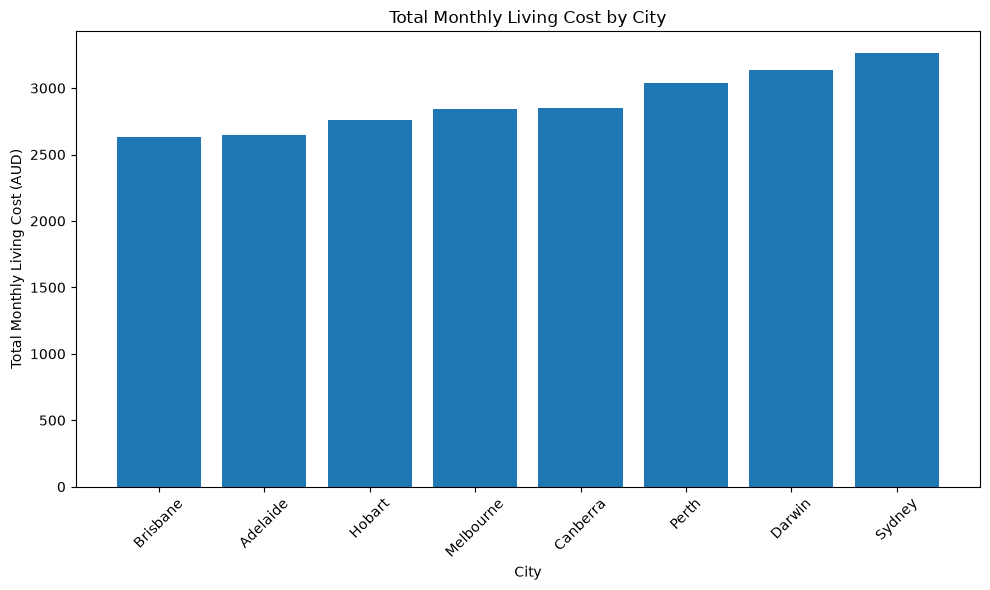

In [27]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_cost_ranking["city"],
    city_cost_ranking["total_monthly_living_cost"]
)

plt.title("Total Monthly Living Cost by City")
plt.xlabel("City")
plt.ylabel("Total Monthly Living Cost (AUD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

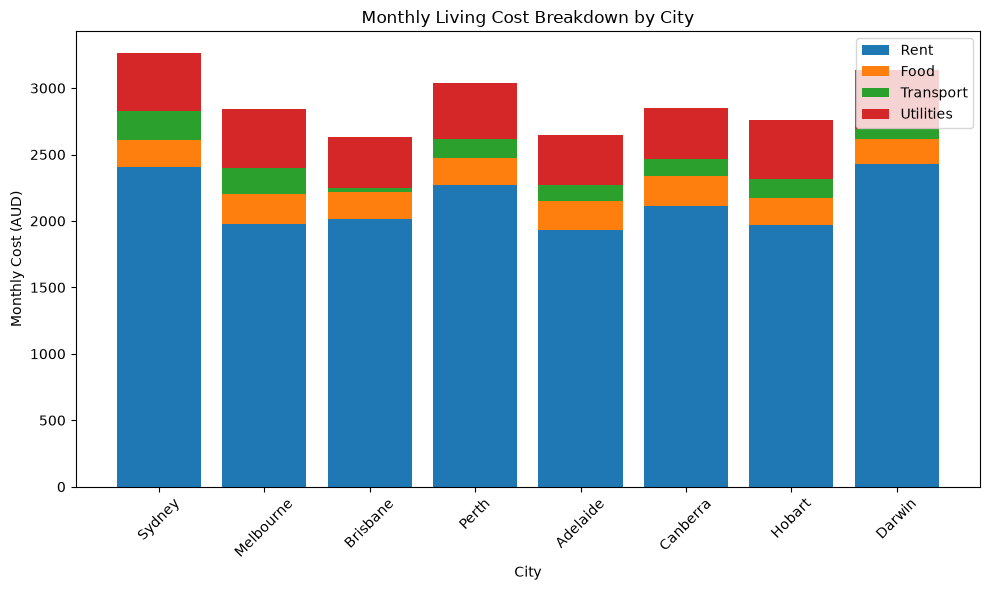

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    df["city"],
    df["monthly_rent_cost"],
    label="Rent"
)

plt.bar(
    df["city"],
    df["monthly_food_cost"],
    bottom=df["monthly_rent_cost"],
    label="Food"
)

plt.bar(
    df["city"],
    df["monthly_transport_cost"],
    bottom=df["monthly_rent_cost"] + df["monthly_food_cost"],
    label="Transport"
)

plt.bar(
    df["city"],
    df["monthly_utilities_cost"],
    bottom=(
        df["monthly_rent_cost"]
        + df["monthly_food_cost"]
        + df["monthly_transport_cost"]
    ),
    label="Utilities"
)

plt.title("Monthly Living Cost Breakdown by City")
plt.xlabel("City")
plt.ylabel("Monthly Cost (AUD)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
df["rent_share_pct"] = (
    df["monthly_rent_cost"]
    / df["total_monthly_living_cost"]
) * 100

rent_share = df[
    ["city", "monthly_rent_cost", "total_monthly_living_cost", "rent_share_pct"]
].sort_values(
    "rent_share_pct",
    ascending=False
).reset_index(drop=True)

rent_share

,city,monthly_rent_cost,total_monthly_living_cost,rent_share_pct
0,Darwin,2426.67,3137.080,77.354419
1,Brisbane,2018.44,2629.145,76.771726
2,Perth,2272.00,3039.830,74.741022
3,Canberra,2111.82,2852.470,74.034784
4,Sydney,2403.33,3264.035,73.630644
5,Adelaide,1930.00,2644.700,72.976141
6,Hobart,1970.00,2760.515,71.363496
7,Melbourne,1979.54,2839.480,69.714877


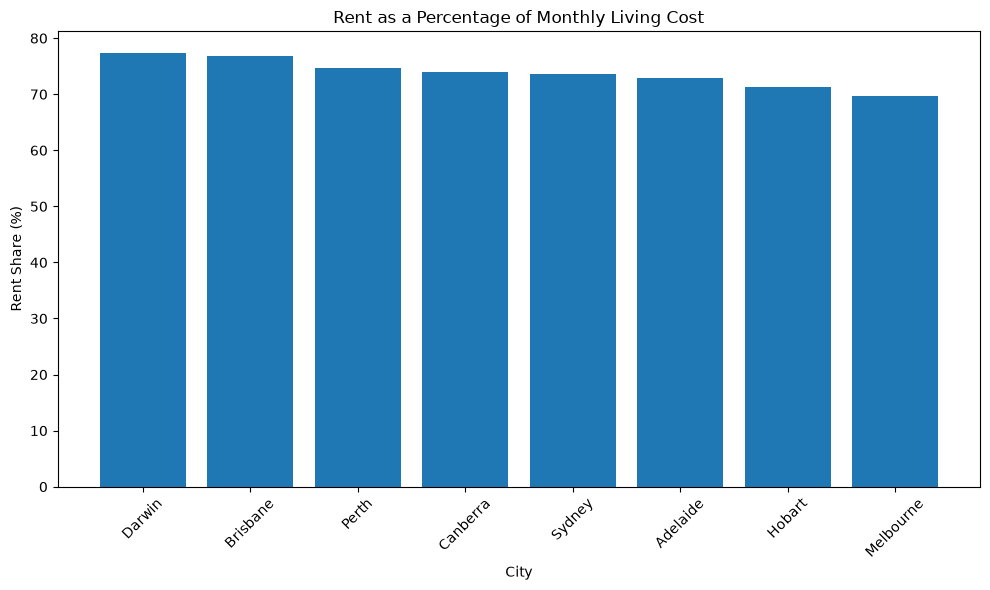

In [30]:
plt.figure(figsize=(10, 6))

plt.bar(
    rent_share["city"],
    rent_share["rent_share_pct"]
)

plt.title("Rent as a Percentage of Monthly Living Cost")
plt.xlabel("City")
plt.ylabel("Rent Share (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
annual_cost_ranking = df[
    ["city", "annual_living_cost"]
].sort_values(
    "annual_living_cost",
    ascending=True
).reset_index(drop=True)

annual_cost_ranking

,city,annual_living_cost
0,Brisbane,31549.74
1,Adelaide,31736.40
2,Hobart,33126.18
3,Melbourne,34073.76
4,Canberra,34229.64
5,Perth,36477.96
6,Darwin,37644.96
7,Sydney,39168.42


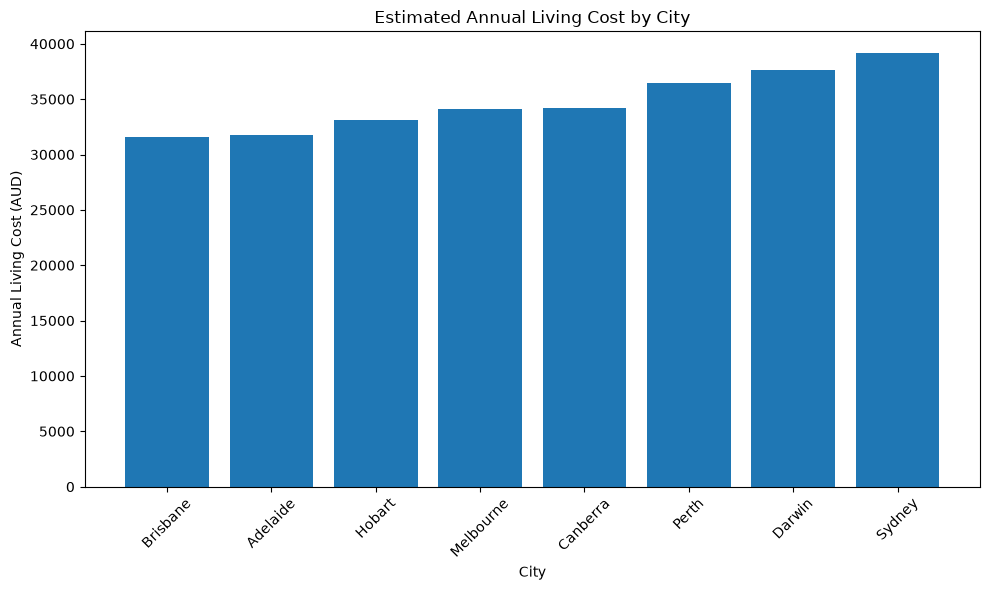

In [32]:
plt.figure(figsize=(10, 6))

plt.bar(
    annual_cost_ranking["city"],
    annual_cost_ranking["annual_living_cost"]
)

plt.title("Estimated Annual Living Cost by City")
plt.xlabel("City")
plt.ylabel("Annual Living Cost (AUD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
category_ranking = df[
    [
        "city",
        "monthly_rent_cost",
        "monthly_food_cost",
        "monthly_transport_cost",
        "monthly_utilities_cost",
        "total_monthly_living_cost"
    ]
].copy()

category_ranking

,city,monthly_rent_cost,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,total_monthly_living_cost
0,Sydney,2403.33,208.315,217.39,435.00,3264.035
1,Melbourne,1979.54,222.060,198.00,439.88,2839.480
2,Brisbane,2018.44,198.945,30.00,381.76,2629.145
3,Perth,2272.00,205.210,140.00,422.62,3039.830
4,Adelaide,1930.00,223.730,120.00,370.97,2644.700
5,Canberra,2111.82,225.430,132.80,382.42,2852.470
6,Hobart,1970.00,202.815,140.00,447.70,2760.515
7,Darwin,2426.67,193.830,69.69,446.89,3137.080


In [34]:
for column in [
    "monthly_rent_cost",
    "monthly_food_cost",
    "monthly_transport_cost",
    "monthly_utilities_cost"
]:
    cheapest_city = df.loc[df[column].idxmin(), "city"]
    cheapest_cost = df[column].min()

    print(f"{column}: {cheapest_city} — A${cheapest_cost:.2f}")

monthly_rent_cost: Adelaide — A$1930.00
monthly_food_cost: Darwin — A$193.83
monthly_transport_cost: Brisbane — A$30.00
monthly_utilities_cost: Adelaide — A$370.97


In [35]:
cheapest_by_category = pd.DataFrame({
    "category": [
        "Rent",
        "Food",
        "Transport",
        "Utilities"
    ],
    "city": [
        df.loc[df["monthly_rent_cost"].idxmin(), "city"],
        df.loc[df["monthly_food_cost"].idxmin(), "city"],
        df.loc[df["monthly_transport_cost"].idxmin(), "city"],
        df.loc[df["monthly_utilities_cost"].idxmin(), "city"]
    ],
    "monthly_cost": [
        df["monthly_rent_cost"].min(),
        df["monthly_food_cost"].min(),
        df["monthly_transport_cost"].min(),
        df["monthly_utilities_cost"].min()
    ]
})

cheapest_by_category

,category,city,monthly_cost
0,Rent,Adelaide,1930.00
1,Food,Darwin,193.83
2,Transport,Brisbane,30.00
3,Utilities,Adelaide,370.97


In [36]:
df["affordability_rank"] = (
    df["total_monthly_living_cost"]
    .rank(method="min", ascending=True)
    .astype(int)
)

affordability_ranking = (
    df[
        [
            "city",
            "monthly_rent_cost",
            "monthly_food_cost",
            "monthly_transport_cost",
            "monthly_utilities_cost",
            "total_monthly_living_cost",
            "affordability_rank"
        ]
    ]
    .sort_values("affordability_rank")
    .reset_index(drop=True)
)

affordability_ranking

,city,monthly_rent_cost,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,total_monthly_living_cost,affordability_rank
0,Brisbane,2018.44,198.945,30.00,381.76,2629.145,1
1,Adelaide,1930.00,223.730,120.00,370.97,2644.700,2
2,Hobart,1970.00,202.815,140.00,447.70,2760.515,3
3,Melbourne,1979.54,222.060,198.00,439.88,2839.480,4
4,Canberra,2111.82,225.430,132.80,382.42,2852.470,5
5,Perth,2272.00,205.210,140.00,422.62,3039.830,6
6,Darwin,2426.67,193.830,69.69,446.89,3137.080,7
7,Sydney,2403.33,208.315,217.39,435.00,3264.035,8


In [37]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. city
2. numbeo_update_date
3. restaurant_inexpensive
4. restaurant_midrange_two
5. mcdonalds_combo
6. domestic_draft_beer
7. imported_beer
8. cappuccino
9. soft_drink
10. water_033l
11. milk_1l
12. bread_500g
13. rice_1kg
14. eggs_12
15. local_cheese_1kg
16. chicken_1kg
17. beef_1kg
18. apples_1kg
19. bananas_1kg
20. oranges_1kg
21. tomatoes_1kg
22. potatoes_1kg
23. onions_1kg
24. lettuce_1head
25. water_15l
26. wine_midrange
27. domestic_beer_05l
28. imported_beer_033l
29. cigarettes_20
30. transport_one_way
31. transport_monthly_pass
32. taxi_start
33. taxi_per_km
34. taxi_wait_hour
35. gasoline_1l
36. utilities_85sqm
37. mobile_plan
38. internet
39. gym_membership
40. tennis_hour
41. cinema_ticket
42. preschool_monthly
43. international_primary_annual
44. jeans
45. summer_dress
46. nike_running_shoes
47. mens_business_shoes
48. rent_1br_city_centre
49. rent_1br_outside_centre
50. rent_3br_city_centre
51. rent_3br_outside_centre
52. buy_price_sqm_city_centre
53. buy_price_sqm_outs

In [38]:
education_df = pd.read_csv("../data/raw/lifecost_education_2026.csv")

education_df.head()

,city,university,course,available,duration_years,annual_tuition_fee_aud,fee_year,delivery,campus,notes
0,Melbourne,RMIT University,Master of Data Science,Yes,2.0,44160.0,2026,On campus,Melbourne City,Official course page; international annual fee
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,2026,On campus,Melbourne City,Course confirmed for 2026; 2026 international ...
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,2026,On campus,Melbourne City,Course confirmed; current official page expose...
3,Melbourne,Deakin University,Master of Data Science,Yes,2.0,44200.0,2026,On campus,Burwood,Official international course page
4,Melbourne,Deakin University,Master of Information Technology,Yes,2.0,44200.0,2026,On campus,Burwood,Official international course page


In [39]:
education_df = pd.read_csv("../data/raw/lifecost_education_2026.csv")

education_df.head()

,city,university,course,available,duration_years,annual_tuition_fee_aud,fee_year,delivery,campus,notes
0,Melbourne,RMIT University,Master of Data Science,Yes,2.0,44160.0,2026,On campus,Melbourne City,Official course page; international annual fee
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,2026,On campus,Melbourne City,Course confirmed for 2026; 2026 international ...
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,2026,On campus,Melbourne City,Course confirmed; current official page expose...
3,Melbourne,Deakin University,Master of Data Science,Yes,2.0,44200.0,2026,On campus,Burwood,Official international course page
4,Melbourne,Deakin University,Master of Information Technology,Yes,2.0,44200.0,2026,On campus,Burwood,Official international course page


In [40]:
education_df.shape

(36, 10)

In [41]:
education_df.columns.tolist()

['city',
 'university',
 'course',
 'available',
 'duration_years',
 'annual_tuition_fee_aud',
 'fee_year',
 'delivery',
 'campus',
 'notes']

In [42]:
lifecost_df = education_df.merge(
    df,
    on="city",
    how="left"
)

lifecost_df.head()

,city,university,course,available,duration_years,annual_tuition_fee_aud,fee_year,delivery,campus,notes,...,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,monthly_rent_cost,total_monthly_living_cost,annual_living_cost,income_after_living_cost,disposable_income_pct,rent_share_pct,affordability_rank
0,Melbourne,RMIT University,Master of Data Science,Yes,2.0,44160.0,2026,On campus,Melbourne City,Official course page; international annual fee,...,222.06,198.0,439.88,1979.54,2839.48,34073.76,3446.63,54.829298,69.714877,4
1,Melbourne,RMIT University,Master of Information Technology,Yes,2.0,NaN,2026,On campus,Melbourne City,Course confirmed for 2026; 2026 international ...,...,222.06,198.0,439.88,1979.54,2839.48,34073.76,3446.63,54.829298,69.714877,4
2,Melbourne,RMIT University,Master of Business Administration,Yes,2.0,NaN,2026,On campus,Melbourne City,Course confirmed; current official page expose...,...,222.06,198.0,439.88,1979.54,2839.48,34073.76,3446.63,54.829298,69.714877,4
3,Melbourne,Deakin University,Master of Data Science,Yes,2.0,44200.0,2026,On campus,Burwood,Official international course page,...,222.06,198.0,439.88,1979.54,2839.48,34073.76,3446.63,54.829298,69.714877,4
4,Melbourne,Deakin University,Master of Information Technology,Yes,2.0,44200.0,2026,On campus,Burwood,Official international course page,...,222.06,198.0,439.88,1979.54,2839.48,34073.76,3446.63,54.829298,69.714877,4


In [43]:
lifecost_df.shape

(36, 77)

In [44]:
lifecost_df[
    [
        "city",
        "university",
        "course",
        "available",
        "annual_tuition_fee_aud",
        "duration_years",
        "total_monthly_living_cost",
        "annual_living_cost"
    ]
].head(10)

,city,university,course,available,annual_tuition_fee_aud,duration_years,total_monthly_living_cost,annual_living_cost
0,Melbourne,RMIT University,Master of Data Science,Yes,44160.0,2.0,2839.480,34073.76
1,Melbourne,RMIT University,Master of Information Technology,Yes,NaN,2.0,2839.480,34073.76
2,Melbourne,RMIT University,Master of Business Administration,Yes,NaN,2.0,2839.480,34073.76
3,Melbourne,Deakin University,Master of Data Science,Yes,44200.0,2.0,2839.480,34073.76
4,Melbourne,Deakin University,Master of Information Technology,Yes,44200.0,2.0,2839.480,34073.76
5,Melbourne,Deakin University,Master of Business Administration,Yes,50400.0,2.0,2839.480,34073.76
6,Melbourne,The University of Melbourne,Master of Data Science,Yes,57984.0,2.0,2839.480,34073.76
7,Melbourne,The University of Melbourne,Master of Information Technology,Yes,NaN,2.0,2839.480,34073.76
8,Melbourne,The University of Melbourne,Master of Business Administration,Yes,56268.0,2.0,2839.480,34073.76
9,Sydney,UNSW Sydney,Master of Data Science,No,NaN,NaN,3264.035,39168.42


In [45]:
valid_lifecost_df = lifecost_df[
    (lifecost_df["available"] == "Yes") &
    (lifecost_df["annual_tuition_fee_aud"].notna()) &
    (lifecost_df["duration_years"].notna())
].copy()

valid_lifecost_df.shape

(18, 77)

In [46]:
valid_lifecost_df["annual_total_cost"] = (
    valid_lifecost_df["annual_tuition_fee_aud"]
    + valid_lifecost_df["annual_living_cost"]
)

valid_lifecost_df[
    [
        "city",
        "university",
        "course",
        "annual_tuition_fee_aud",
        "annual_living_cost",
        "annual_total_cost"
    ]
].head(10)

,city,university,course,annual_tuition_fee_aud,annual_living_cost,annual_total_cost
0,Melbourne,RMIT University,Master of Data Science,44160.0,34073.76,78233.76
3,Melbourne,Deakin University,Master of Data Science,44200.0,34073.76,78273.76
4,Melbourne,Deakin University,Master of Information Technology,44200.0,34073.76,78273.76
5,Melbourne,Deakin University,Master of Business Administration,50400.0,34073.76,84473.76
6,Melbourne,The University of Melbourne,Master of Data Science,57984.0,34073.76,92057.76
8,Melbourne,The University of Melbourne,Master of Business Administration,56268.0,34073.76,90341.76
10,Sydney,UNSW Sydney,Master of Information Technology,63000.0,39168.42,102168.42
11,Sydney,UNSW Sydney,Master of Business Administration,83500.0,39168.42,122668.42
15,Brisbane,University of Queensland,Master of Data Science,60952.0,31549.74,92501.74
16,Brisbane,University of Queensland,Master of Information Technology,58056.0,31549.74,89605.74


In [47]:
valid_lifecost_df["estimated_total_masters_cost"] = (
    valid_lifecost_df["annual_total_cost"]
    * valid_lifecost_df["duration_years"]
)

valid_lifecost_df[
    [
        "city",
        "university",
        "course",
        "duration_years",
        "annual_total_cost",
        "estimated_total_masters_cost"
    ]
].head(10)

,city,university,course,duration_years,annual_total_cost,estimated_total_masters_cost
0,Melbourne,RMIT University,Master of Data Science,2.0,78233.76,156467.52
3,Melbourne,Deakin University,Master of Data Science,2.0,78273.76,156547.52
4,Melbourne,Deakin University,Master of Information Technology,2.0,78273.76,156547.52
5,Melbourne,Deakin University,Master of Business Administration,2.0,84473.76,168947.52
6,Melbourne,The University of Melbourne,Master of Data Science,2.0,92057.76,184115.52
8,Melbourne,The University of Melbourne,Master of Business Administration,2.0,90341.76,180683.52
10,Sydney,UNSW Sydney,Master of Information Technology,2.0,102168.42,204336.84
11,Sydney,UNSW Sydney,Master of Business Administration,1.0,122668.42,122668.42
15,Brisbane,University of Queensland,Master of Data Science,2.0,92501.74,185003.48
16,Brisbane,University of Queensland,Master of Information Technology,2.0,89605.74,179211.48


In [48]:
master_cost_table = valid_lifecost_df[
    [
        "city",
        "university",
        "course",
        "duration_years",
        "annual_tuition_fee_aud",
        "annual_living_cost",
        "annual_total_cost",
        "estimated_total_masters_cost"
    ]
].sort_values(
    ["city", "university", "course"]
).reset_index(drop=True)

master_cost_table

,city,university,course,duration_years,annual_tuition_fee_aud,annual_living_cost,annual_total_cost,estimated_total_masters_cost
0,Adelaide,Adelaide University,Master of Business Administration,1.5,54900.0,31736.40,86636.40,129954.60
1,Adelaide,Adelaide University,Master of Data Science,2.0,57100.0,31736.40,88836.40,177672.80
2,Brisbane,James Cook University,Master of Business Administration,1.5,33133.0,31549.74,64682.74,97024.11
3,Brisbane,University of Queensland,Master of Business Administration,1.5,69112.0,31549.74,100661.74,150992.61
4,Brisbane,University of Queensland,Master of Data Science,2.0,60952.0,31549.74,92501.74,185003.48
5,Brisbane,University of Queensland,Master of Information Technology,2.0,58056.0,31549.74,89605.74,179211.48
6,Canberra,University of Canberra,Master of Data Science,2.0,42000.0,34229.64,76229.64,152459.28
7,Darwin,Charles Darwin University,Master of Business Administration,1.5,38560.0,37644.96,76204.96,114307.44
8,Darwin,Charles Darwin University,Master of Data Science,2.0,36809.0,37644.96,74453.96,148907.92
9,Melbourne,Deakin University,Master of Business Administration,2.0,50400.0,34073.76,84473.76,168947.52


In [49]:
lifecost_final = valid_lifecost_df[
    [
        "city",
        "university",
        "course",
        "duration_years",
        "annual_tuition_fee_aud",
        "monthly_rent_cost",
        "monthly_food_cost",
        "monthly_transport_cost",
        "monthly_utilities_cost",
        "total_monthly_living_cost",
        "annual_living_cost",
        "annual_total_cost",
        "estimated_total_masters_cost"
    ]
].copy()

lifecost_final.head()

,city,university,course,duration_years,annual_tuition_fee_aud,monthly_rent_cost,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,total_monthly_living_cost,annual_living_cost,annual_total_cost,estimated_total_masters_cost
0,Melbourne,RMIT University,Master of Data Science,2.0,44160.0,1979.54,222.06,198.0,439.88,2839.48,34073.76,78233.76,156467.52
3,Melbourne,Deakin University,Master of Data Science,2.0,44200.0,1979.54,222.06,198.0,439.88,2839.48,34073.76,78273.76,156547.52
4,Melbourne,Deakin University,Master of Information Technology,2.0,44200.0,1979.54,222.06,198.0,439.88,2839.48,34073.76,78273.76,156547.52
5,Melbourne,Deakin University,Master of Business Administration,2.0,50400.0,1979.54,222.06,198.0,439.88,2839.48,34073.76,84473.76,168947.52
6,Melbourne,The University of Melbourne,Master of Data Science,2.0,57984.0,1979.54,222.06,198.0,439.88,2839.48,34073.76,92057.76,184115.52


In [50]:
lifecost_final.to_csv(
    "../data/processed/lifecost_final_2026.csv",
    index=False
)

In [51]:
selected = lifecost_final[
    (lifecost_final["city"] == "Melbourne") &
    (lifecost_final["university"] == "RMIT University") &
    (lifecost_final["course"] == "Master of Data Science")
]

selected

,city,university,course,duration_years,annual_tuition_fee_aud,monthly_rent_cost,monthly_food_cost,monthly_transport_cost,monthly_utilities_cost,total_monthly_living_cost,annual_living_cost,annual_total_cost,estimated_total_masters_cost
0,Melbourne,RMIT University,Master of Data Science,2.0,44160.0,1979.54,222.06,198.0,439.88,2839.48,34073.76,78233.76,156467.52


In [54]:
food_cols = [
    "milk_1l",
    "bread_500g",
    "rice_1kg",
    "eggs_12",
    "local_cheese_1kg",
    "chicken_1kg",
    "beef_1kg",
    "apples_1kg",
    "bananas_1kg",
    "oranges_1kg",
    "tomatoes_1kg",
    "potatoes_1kg",
    "onions_1kg",
    "lettuce_1head",
    "water_15l"
]

frontend_df = lifecost_final.merge(
    df[[
        "city",
        *food_cols,
        "utilities_85sqm",
        "internet",
        "mobile_plan",
        "transport_monthly_pass",
        "rent_1br_outside_centre"
    ]],
    on="city",
    how="left"
)

frontend_df.shape

(18, 33)

In [55]:
test_student = frontend_df[
    (frontend_df["city"] == "Melbourne") &
    (frontend_df["university"] == "RMIT University") &
    (frontend_df["course"] == "Master of Data Science")
]

test_student.T

,0
city,Melbourne
university,RMIT University
course,Master of Data Science
duration_years,2.0
annual_tuition_fee_aud,44160.0
monthly_rent_cost,1979.54
monthly_food_cost,222.06
monthly_transport_cost,198.0
monthly_utilities_cost,439.88
total_monthly_living_cost,2839.48


In [56]:
student_result = {
    "education": {
        "university": test_student.iloc[0]["university"],
        "course": test_student.iloc[0]["course"],
        "duration_years": test_student.iloc[0]["duration_years"],
        "annual_tuition_fee": test_student.iloc[0]["annual_tuition_fee_aud"]
    },

    "housing": {
        "total_monthly": test_student.iloc[0]["monthly_rent_cost"],
        "rent_1br_outside_centre": test_student.iloc[0]["rent_1br_outside_centre"]
    },

    "food": {
        "total_monthly": test_student.iloc[0]["monthly_food_cost"],
        "items": {
            "Milk (1L)": test_student.iloc[0]["milk_1l"],
            "Bread (500g)": test_student.iloc[0]["bread_500g"],
            "Rice (1kg)": test_student.iloc[0]["rice_1kg"],
            "Eggs (12)": test_student.iloc[0]["eggs_12"],
            "Cheese (1kg)": test_student.iloc[0]["local_cheese_1kg"],
            "Chicken (1kg)": test_student.iloc[0]["chicken_1kg"],
            "Beef (1kg)": test_student.iloc[0]["beef_1kg"],
            "Apples (1kg)": test_student.iloc[0]["apples_1kg"],
            "Bananas (1kg)": test_student.iloc[0]["bananas_1kg"],
            "Oranges (1kg)": test_student.iloc[0]["oranges_1kg"],
            "Tomatoes (1kg)": test_student.iloc[0]["tomatoes_1kg"],
            "Potatoes (1kg)": test_student.iloc[0]["potatoes_1kg"],
            "Onions (1kg)": test_student.iloc[0]["onions_1kg"],
            "Lettuce (1 head)": test_student.iloc[0]["lettuce_1head"],
            "Water (1.5L)": test_student.iloc[0]["water_15l"]
        }
    },

    "transport": {
        "total_monthly": test_student.iloc[0]["monthly_transport_cost"],
        "monthly_pass": test_student.iloc[0]["transport_monthly_pass"]
    },

    "utilities": {
        "total_monthly": test_student.iloc[0]["monthly_utilities_cost"],
        "utilities": test_student.iloc[0]["utilities_85sqm"],
        "internet": test_student.iloc[0]["internet"],
        "mobile": test_student.iloc[0]["mobile_plan"]
    },

    "summary": {
        "monthly_living_cost": test_student.iloc[0]["total_monthly_living_cost"],
        "annual_living_cost": test_student.iloc[0]["annual_living_cost"],
        "annual_total_cost": test_student.iloc[0]["annual_total_cost"],
        "estimated_total_masters_cost": test_student.iloc[0]["estimated_total_masters_cost"]
    }
}

student_result

{'education': {'university': 'RMIT University',
  'course': 'Master of Data Science',
  'duration_years': np.float64(2.0),
  'annual_tuition_fee': np.float64(44160.0)},
 'housing': {'total_monthly': np.float64(1979.54),
  'rent_1br_outside_centre': np.float64(1979.54)},
 'food': {'total_monthly': np.float64(222.06),
  'items': {'Milk (1L)': np.float64(2.46),
   'Bread (500g)': np.float64(4.61),
   'Rice (1kg)': np.float64(4.0),
   'Eggs (12)': np.float64(8.49),
   'Cheese (1kg)': np.float64(15.14),
   'Chicken (1kg)': np.float64(13.62),
   'Beef (1kg)': np.float64(21.64),
   'Apples (1kg)': np.float64(5.95),
   'Bananas (1kg)': np.float64(4.43),
   'Oranges (1kg)': np.float64(4.76),
   'Tomatoes (1kg)': np.float64(6.92),
   'Potatoes (1kg)': np.float64(4.66),
   'Onions (1kg)': np.float64(3.87),
   'Lettuce (1 head)': np.float64(3.56),
   'Water (1.5L)': np.float64(2.32)}},
 'transport': {'total_monthly': np.float64(198.0),
  'monthly_pass': np.float64(198.0)},
 'utilities': {'total_mo

In [57]:
def get_lifecost(city, university, course):

    selected = frontend_df[
        (frontend_df["city"] == city) &
        (frontend_df["university"] == university) &
        (frontend_df["course"] == course)
    ]

    if selected.empty:
        return None

    row = selected.iloc[0]

    result = {
        "education": {
            "university": row["university"],
            "course": row["course"],
            "duration_years": float(row["duration_years"]),
            "annual_tuition_fee": float(row["annual_tuition_fee_aud"])
        },

        "housing": {
            "total_monthly": float(row["monthly_rent_cost"]),
            "rent_1br_outside_centre": float(row["rent_1br_outside_centre"])
        },

        "food": {
            "total_monthly": float(row["monthly_food_cost"]),
            "items": {
                "Milk (1L)": float(row["milk_1l"]),
                "Bread (500g)": float(row["bread_500g"]),
                "Rice (1kg)": float(row["rice_1kg"]),
                "Eggs (12)": float(row["eggs_12"]),
                "Cheese (1kg)": float(row["local_cheese_1kg"]),
                "Chicken (1kg)": float(row["chicken_1kg"]),
                "Beef (1kg)": float(row["beef_1kg"]),
                "Apples (1kg)": float(row["apples_1kg"]),
                "Bananas (1kg)": float(row["bananas_1kg"]),
                "Oranges (1kg)": float(row["oranges_1kg"]),
                "Tomatoes (1kg)": float(row["tomatoes_1kg"]),
                "Potatoes (1kg)": float(row["potatoes_1kg"]),
                "Onions (1kg)": float(row["onions_1kg"]),
                "Lettuce (1 head)": float(row["lettuce_1head"]),
                "Water (1.5L)": float(row["water_15l"])
            }
        },

        "transport": {
            "total_monthly": float(row["monthly_transport_cost"]),
            "monthly_pass": float(row["transport_monthly_pass"])
        },

        "utilities": {
            "total_monthly": float(row["monthly_utilities_cost"]),
            "utilities": float(row["utilities_85sqm"]),
            "internet": float(row["internet"]),
            "mobile": float(row["mobile_plan"])
        },

        "summary": {
            "monthly_living_cost": float(row["total_monthly_living_cost"]),
            "annual_living_cost": float(row["annual_living_cost"]),
            "annual_total_cost": float(row["annual_total_cost"]),
            "estimated_total_masters_cost": float(row["estimated_total_masters_cost"])
        }
    }

    return result

In [58]:
result = get_lifecost(
    "Melbourne",
    "RMIT University",
    "Master of Data Science"
)

result

{'education': {'university': 'RMIT University',
  'course': 'Master of Data Science',
  'duration_years': 2.0,
  'annual_tuition_fee': 44160.0},
 'housing': {'total_monthly': 1979.54, 'rent_1br_outside_centre': 1979.54},
 'food': {'total_monthly': 222.06,
  'items': {'Milk (1L)': 2.46,
   'Bread (500g)': 4.61,
   'Rice (1kg)': 4.0,
   'Eggs (12)': 8.49,
   'Cheese (1kg)': 15.14,
   'Chicken (1kg)': 13.62,
   'Beef (1kg)': 21.64,
   'Apples (1kg)': 5.95,
   'Bananas (1kg)': 4.43,
   'Oranges (1kg)': 4.76,
   'Tomatoes (1kg)': 6.92,
   'Potatoes (1kg)': 4.66,
   'Onions (1kg)': 3.87,
   'Lettuce (1 head)': 3.56,
   'Water (1.5L)': 2.32}},
 'transport': {'total_monthly': 198.0, 'monthly_pass': 198.0},
 'utilities': {'total_monthly': 439.87999999999994,
  'utilities': 320.71,
  'internet': 79.47,
  'mobile': 39.7},
 'summary': {'monthly_living_cost': 2839.48,
  'annual_living_cost': 34073.76,
  'annual_total_cost': 78233.76000000001,
  'estimated_total_masters_cost': 156467.52000000002}}

In [59]:
food_quantities = {
    "Milk (1L)": 8,
    "Bread (500g)": 8,
    "Rice (1kg)": 4,
    "Eggs (12)": 2,
    "Cheese (1kg)": 0.5,
    "Chicken (1kg)": 2,
    "Beef (1kg)": 1,
    "Apples (1kg)": 2,
    "Bananas (1kg)": 2,
    "Oranges (1kg)": 1,
    "Tomatoes (1kg)": 2,
    "Potatoes (1kg)": 2,
    "Onions (1kg)": 1,
    "Lettuce (1 head)": 4,
    "Water (1.5L)": 4
}

food_column_map = {
    "Milk (1L)": "milk_1l",
    "Bread (500g)": "bread_500g",
    "Rice (1kg)": "rice_1kg",
    "Eggs (12)": "eggs_12",
    "Cheese (1kg)": "local_cheese_1kg",
    "Chicken (1kg)": "chicken_1kg",
    "Beef (1kg)": "beef_1kg",
    "Apples (1kg)": "apples_1kg",
    "Bananas (1kg)": "bananas_1kg",
    "Oranges (1kg)": "oranges_1kg",
    "Tomatoes (1kg)": "tomatoes_1kg",
    "Potatoes (1kg)": "potatoes_1kg",
    "Onions (1kg)": "onions_1kg",
    "Lettuce (1 head)": "lettuce_1head",
    "Water (1.5L)": "water_15l"
}

In [60]:
food_breakdown = {}

for item, quantity in food_quantities.items():
    unit_price = float(test_student.iloc[0][food_column_map[item]])
    
    food_breakdown[item] = {
        "unit_price": unit_price,
        "monthly_quantity": quantity,
        "monthly_cost": round(unit_price * quantity, 2)
    }

food_breakdown

{'Milk (1L)': {'unit_price': 2.46,
  'monthly_quantity': 8,
  'monthly_cost': 19.68},
 'Bread (500g)': {'unit_price': 4.61,
  'monthly_quantity': 8,
  'monthly_cost': 36.88},
 'Rice (1kg)': {'unit_price': 4.0,
  'monthly_quantity': 4,
  'monthly_cost': 16.0},
 'Eggs (12)': {'unit_price': 8.49,
  'monthly_quantity': 2,
  'monthly_cost': 16.98},
 'Cheese (1kg)': {'unit_price': 15.14,
  'monthly_quantity': 0.5,
  'monthly_cost': 7.57},
 'Chicken (1kg)': {'unit_price': 13.62,
  'monthly_quantity': 2,
  'monthly_cost': 27.24},
 'Beef (1kg)': {'unit_price': 21.64,
  'monthly_quantity': 1,
  'monthly_cost': 21.64},
 'Apples (1kg)': {'unit_price': 5.95,
  'monthly_quantity': 2,
  'monthly_cost': 11.9},
 'Bananas (1kg)': {'unit_price': 4.43,
  'monthly_quantity': 2,
  'monthly_cost': 8.86},
 'Oranges (1kg)': {'unit_price': 4.76,
  'monthly_quantity': 1,
  'monthly_cost': 4.76},
 'Tomatoes (1kg)': {'unit_price': 6.92,
  'monthly_quantity': 2,
  'monthly_cost': 13.84},
 'Potatoes (1kg)': {'unit_p